In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 

from wordcloud import WordCloud 

In [2]:
df_thr = pd.read_excel('../datasets/03_labeling.xlsx')
df_thr.info()
df_thr.head()

<class 'pandas.DataFrame'>
RangeIndex: 1758 entries, 0 to 1757
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   platform          1758 non-null   str  
 1   text              1758 non-null   str  
 2   cleaning          1758 non-null   str  
 3   case_folding      1758 non-null   str  
 4   normalisasi_kata  1758 non-null   str  
 5   tokenize          1758 non-null   str  
 6   stopword removal  1758 non-null   str  
 7   stemming          1758 non-null   str  
 8   score             1758 non-null   int64
 9   sentiment         1758 non-null   str  
dtypes: int64(1), str(9)
memory usage: 137.5 KB


,platform,text,cleaning,case_folding,normalisasi_kata,tokenize,stopword removal,stemming,score,sentiment
0,tiktok,asa te boga walikota..hanya KDM yg ku punya,asa te boga walikotahanya KDM yg ku punya,asa te boga walikotahanya kdm yg ku punya,"asa henteu boga wali kota, hanya kdm yang ku p...","['asa', 'henteu', 'boga', 'wali', 'kota,', 'ha...","asa henteu boga wali kota, kdm ku",asa henteu boga wali kota kdm ku,-1,Negatif
1,tiktok,sedih gara gara bapak ini,sedih gara gara bapak ini,sedih gara gara bapak ini,sedih gara gara bapak ini,"['sedih', 'gara', 'gara', 'bapak', 'ini']",sedih gara gara,sedih gara gara,-3,Negatif
2,tiktok,"hade goreng ku basa, ieu mah Pareum we eweuh k...",hade goreng ku basa ieu mah Pareum we eweuh kl...,hade goreng ku basa ieu mah pareum we eweuh kl...,hade goreng ku basa ieu mah pareum we eweuh kl...,"['hade', 'goreng', 'ku', 'basa', 'ieu', 'mah',...",hade goreng ku basa ieu mah pareum we eweuh kl...,hade goreng ku basa ieu mah pareum we eweuh kl...,-2,Negatif
3,tiktok,Ciamis ts cair Minggu kmari .Tasik mah kmha ce...,Ciamis ts cair Minggu kmari Tasik mah kmha cer...,ciamis ts cair minggu kmari tasik mah kmha cer...,ciamis atos cair minggu kamari tasikmalaya mah...,"['ciamis', 'atos', 'cair', 'minggu', 'kamari',...",ciamis atos cair minggu kamari tasikmalaya mah...,ciamis atos cair minggu kamar tasikmalaya mah ...,0,Negatif
4,tiktok,nyesel milih dia,nyesel milih dia,nyesel milih dia,menyesal memilih dia,"['menyesal', 'memilih', 'dia']",menyesal memilih,sesal pilih,-1,Negatif


# **4. VISUALIZATION**

In [3]:
from wordcloud import WordCloud, STOPWORDS

base_stopwords = set(STOPWORDS)

vectorizer_stopwords = set()

for word in base_stopwords:
    tokens = word.lower().replace("'", "").split()

    for token in tokens:
        if token.isalpha():
            vectorizer_stopwords.add(token)

base_stopwords.update({
    # Bahasa Sunda / kata umum
    'bp', 'pa', 'nu', 'ge', 'anu', 'bu',
    'teu', 'mah', 'weh', 'abi', 'kang',
    'si', 'krna', 'ah', 'gak', 'gk',
    'atuh', 'geus', 'kan', 'jeung',
    'ttp', 'oge', 'te', 'tuh', 'yaa',
    'sih', 'yang', 'lho', 'ek',
    'boa', 'kn', 'di', 'keur',
    'ka', 'ari', 'da', 'wae',
    'usah', 'jd', 'asa', 'ges',
    'mh', 'dong', 'tah', 'et',
    'ku', 'tp', 'ti', 'aja',
    'ieu', 'ke', 'pada', 'ga',
    'biar', 'pk', 'dll', 'lah',
    'tos', 'tdk', 'klo', 'ya',
    'itu', 'sll', 'sblm', 'dah',
    'teh', 'ttp'

    # Singkatan / kata kurang informatif
    'nya', 'sdh', 'loh', 'n',
    'jas', 'rb', 'dn', 'jga',
    'jln', 'jg', 'pisan', 'cik',
    'keneh', 'gening', 'deui',
    'se', 'sm', 'smg', 'skr',
    'udh', 'nih', 'tgl',
    'p', 'g', 'h', 'l', 'i',
    'x', 'pp', 'pw', 'ath',
    'ter', 'klu', 'dr'
})

## **4.1 Wordcloud**

In [4]:
def create_wordcloud(
    data,
    sentiment=None,
    text_column='normalisasi_kata',
    sentiment_column='sentiment',
    stopwords=None,
    colormap='viridis',
    title='Word Cloud',
    filename=None
):
    
    # Ambil teks
    if sentiment is None:
        # General = semua data
        text_data = data[text_column]
    else:
        # Berdasarkan sentiment
        text_data = data.loc[
            data[sentiment_column].str.lower() == sentiment.lower(),
            text_column
        ]

    # Hapus missing value
    text_data = text_data.dropna().astype(str)

    # Gabungkan seluruh teks
    teks = " ".join(text_data)

    # Cek apakah teks tersedia
    if not teks.strip():
        print(f"Tidak ada data untuk {title}")
        return

    # Generate WordCloud
    wc = WordCloud(
        width=1400,
        height=500,
        background_color='white',
        stopwords=stopwords,
        max_words=1000,
        colormap=colormap,
        prefer_horizontal=0.9,
        relative_scaling=0.5,
        min_font_size=8,
        max_font_size=120
    ).generate(teks)

    # Visualisasi
    plt.figure(figsize=(16, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=25, fontweight='bold', pad=20)

    # Simpan gambar
    if filename:
        os.makedirs(os.path.dirname(filename), exist_ok=True)
        plt.savefig(filename, dpi=300, bbox_inches='tight', pad_inches=0.5)

    plt.show()

### **4.1.1 Wordcloud General**

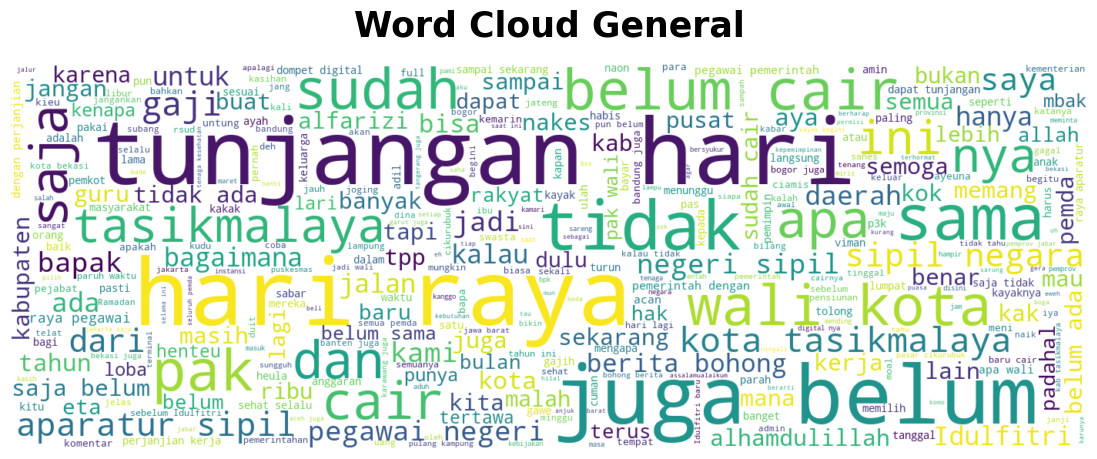

In [5]:
create_wordcloud(
    df_thr,
    sentiment=None,
    text_column='normalisasi_kata',
    stopwords=base_stopwords,
    colormap='viridis',
    title='Word Cloud General',
    filename='../img/04 wc_general.png'
)

### **4.1.2 Worcloud Positif**

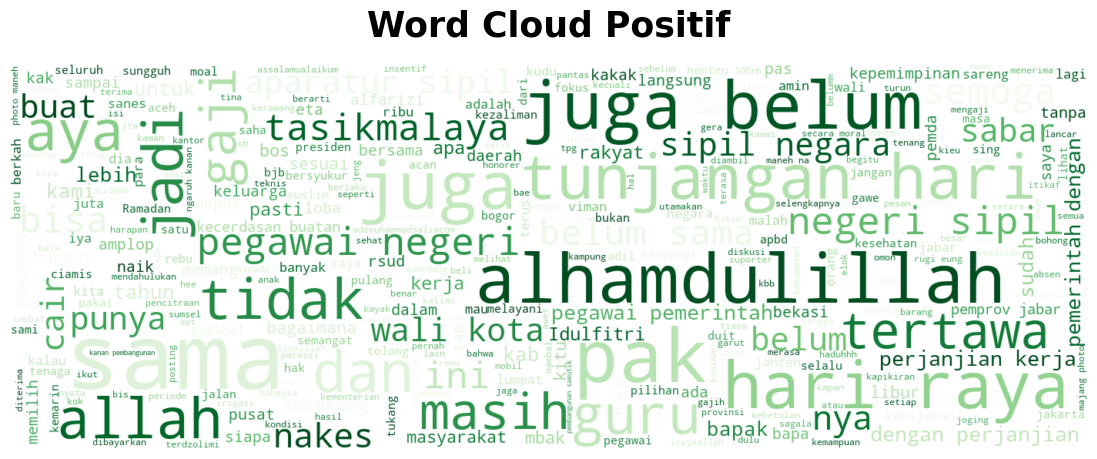

In [6]:
create_wordcloud(
    df_thr,
    sentiment='Positif',
    text_column='normalisasi_kata',
    stopwords=base_stopwords,
    colormap='Greens',
    title='Word Cloud Positif',
    filename='../img/04 wc_positif.png'
)

### **4.1.3 Wordcloud Negatif**

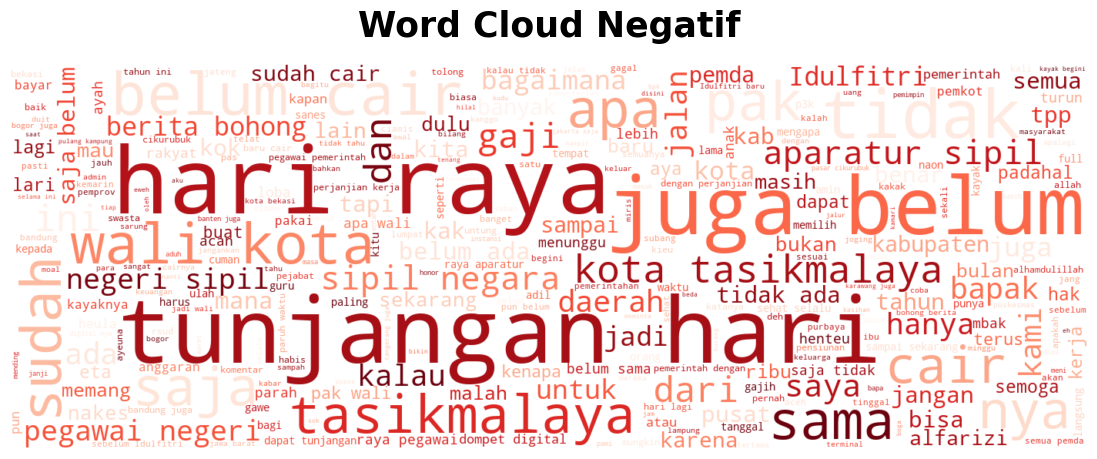

In [7]:
create_wordcloud(
    df_thr,
    sentiment='Negatif',
    text_column='normalisasi_kata',
    stopwords=base_stopwords,
    colormap='Reds',
    title='Word Cloud Negatif',
    filename='../img/04 wc_negatif.png'
)

### **4.1.4 Wordcloud Netral**

In [8]:
create_wordcloud(
    df_thr,
    sentiment='Netral',
    text_column='normalisasi_kata',
    stopwords=base_stopwords,
    colormap='Blues',
    title='Word Cloud Netral',
    filename='../img/04 wc_netral.png'
)

Tidak ada data untuk Word Cloud Netral


## **4.2 Frekuenisi Kata (Unigram)**

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_unigram(
    data,
    sentiment_label=None,
    text_column='normalisasi_kata',
    sentiment_column='sentiment',
    top_n=15,
    color='blue',
    filename=None
):
    
    # Filter data
    if sentiment_label is None:
        # General = seluruh data
        text_data = data[text_column]
        title_label = 'General'
    else:
        # Berdasarkan sentiment
        text_data = data.loc[
            data[sentiment_column].str.lower() == sentiment_label.lower(),text_column
        ]
        title_label = sentiment_label.capitalize()

    # Hapus missing value
    text_data = text_data.dropna().astype(str)

    # Cek apakah data tersedia
    if text_data.empty or not text_data.str.strip().any():
        print(
            f"Tidak ada data untuk "
            f"{top_n} Unigram Top Word - {title_label}"
        )
        return

    # CountVectorizer
    # Unigram = kata tunggal
    vectorizer = CountVectorizer(
        ngram_range=(1, 1),
        stop_words=list(vectorizer_stopwords),
        token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b'
    )

    X = vectorizer.fit_transform(text_data)

    # Cek apakah ada kata
    # setelah stopword removal
    if len(vectorizer.get_feature_names_out()) == 0:
        print(
            f"Tidak ada kata informatif untuk "
            f"{top_n} Unigram Top Word - {title_label}"
        )
        return

    # Hitung frekuensi kata
    freq_df = pd.DataFrame({
        'kata': vectorizer.get_feature_names_out(),
        'frekuensi': X.sum(axis=0).A1
    })

    # Total seluruh kemunculan kata
    total = freq_df['frekuensi'].sum()

    # Hitung persentase
    freq_df['persentase'] = (
        freq_df['frekuensi'] / total * 100
    )

    # Urutkan dan ambil Top N
    freq_df = (
        freq_df
        .sort_values(by='frekuensi', ascending=False)
        .head(top_n)
    )

    # Visualisasi
    plt.figure(figsize=(10, 6))

    bars = plt.barh(
        freq_df['kata'],
        freq_df['frekuensi'],
        color=color
    )

    # Frekuensi terbesar di atas
    plt.gca().invert_yaxis()

    plt.xlabel('Frekuensi', fontsize=12)
    plt.ylabel('Kata', fontsize=12)

    plt.title(
        f'{top_n} Unigram Top Word - {title_label}',
        fontsize=14,
        fontweight='bold',
        pad=15
    )

    # Label Frekuensi + Persentase
    for bar, (_, row) in zip(
        bars,
        freq_df.iterrows()
    ):

        frequency = int(row['frekuensi'])
        percentage = row['persentase']

        plt.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'{frequency} ({percentage:.2f}%)',
            va='center',
            ha='left',
            fontsize=9
        )

    # Beri ruang untuk label
    plt.xlim(
        0,
        freq_df['frekuensi'].max() * 1.20
    )

    plt.tight_layout()

    # Simpan gambar
    if filename:
        os.makedirs(
            os.path.dirname(filename),
            exist_ok=True
        )

        plt.savefig(
            filename,
            dpi=300,
            bbox_inches='tight'
        )

    plt.show()

    # Kembalikan dataframe
    return freq_df

### **4.2.1 Frekuensi Kata General - Unigram**

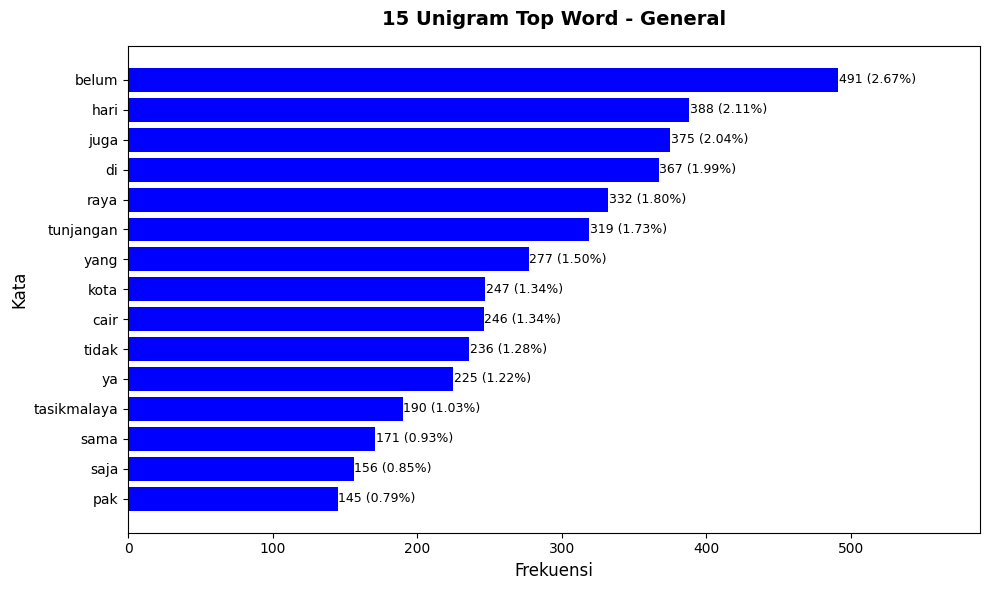

In [10]:
freq_general = plot_top_unigram(
    df_thr,
    sentiment_label=None,
    text_column='normalisasi_kata',
    top_n=15,
    color='blue',
    filename='../img/04 Unigram Top Word General.png'
)

### **4.2.2 Frekuensi Kata Positif - Unigram**

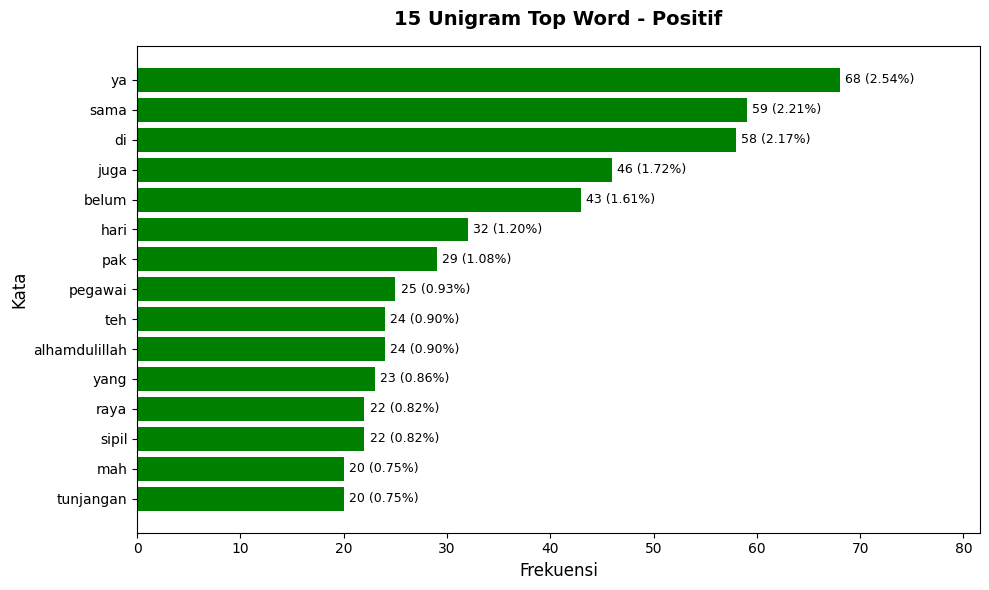

In [11]:
freq_positif = plot_top_unigram(
    df_thr,
    sentiment_label='Positif',
    text_column='normalisasi_kata',
    top_n=15,
    color='green',
    filename='../img/04 Unigram Top Word Positif.png'
)

### **4.2.3 Frekuensi Kata Negatif - Unigram**

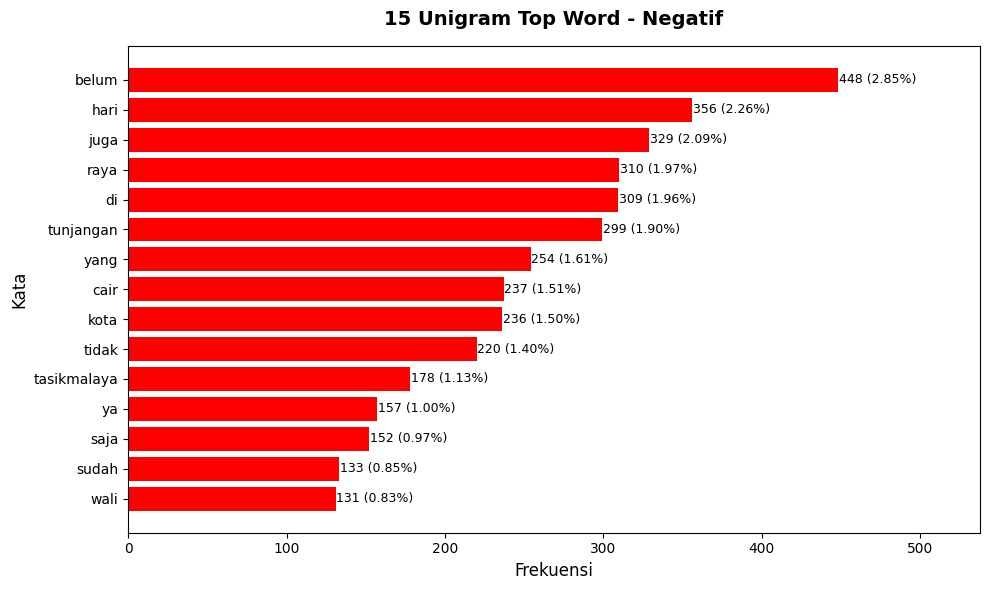

In [12]:
freq_negatif = plot_top_unigram(
    df_thr,
    sentiment_label='Negatif',
    text_column='normalisasi_kata',
    top_n=15,
    color='red',
    filename='../img/04 Unigram Top Word Negatif.png'
)

### **4.2.4 Frekuensi Kata Netral - Unigram**

In [13]:
freq_netral = plot_top_unigram(
    df_thr,
    sentiment_label='Netral',
    text_column='normalisasi_kata',
    top_n=15,
    color='gray',
    filename='../img/04 Unigram Top Word Netral.png'
)

Tidak ada data untuk 15 Unigram Top Word - Netral


## **4.3 Frekuensi Kata (Trigram)**

In [14]:
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_trigram(
    data,
    sentiment_label=None,
    text_column='normalisasi_kata',
    sentiment_column='sentiment',
    top_n=15,
    color='blue',
    filename=None
):
    
    # Filter data
    if sentiment_label is None:
        # General = seluruh data
        text_data = data[text_column]
        title_label = 'Keseluruhan'
    else:
        # Berdasarkan sentiment
        text_data = data.loc[
            data[sentiment_column].str.lower() == sentiment_label.lower(), text_column
        ]
        title_label = sentiment_label.capitalize()

    # Hapus missing value
    text_data = text_data.dropna().astype(str)

    # Cek data tersedia
    if text_data.empty or not text_data.str.strip().any():
        print(
            f"Tidak ada data untuk "
            f"{top_n} Trigram Top Word - {title_label}"
        )
        return

    # CountVectorizer
    # Trigram = 3 kata
    vectorizer = CountVectorizer(
        ngram_range=(3, 3),
        stop_words=list(vectorizer_stopwords),
    )

    X = vectorizer.fit_transform(text_data)

    # Cek apakah ada trigram
    if len(vectorizer.get_feature_names_out()) == 0:
        print(
            f"Tidak ada trigram untuk "
            f"{top_n} Trigram Top Word - {title_label}"
        )
        return

    # Hitung frekuensi
    freq_df = pd.DataFrame({
        'trigram': vectorizer.get_feature_names_out(),
        'frekuensi': X.sum(axis=0).A1
    })

    # Total seluruh trigram
    total = freq_df['frekuensi'].sum()

    # Persentase
    freq_df['persentase'] = (
        freq_df['frekuensi'] / total * 100
    )

    # Urutkan dan ambil Top N
    freq_df = (
        freq_df
        .sort_values(
            by='frekuensi',
            ascending=False
        )
        .head(top_n)
    )

    # Visualisasi
    plt.figure(figsize=(11, 7))

    bars = plt.barh(
        freq_df['trigram'],
        freq_df['frekuensi'],
        color=color
    )

    # Frekuensi terbesar di atas
    plt.gca().invert_yaxis()

    plt.xlabel('Frekuensi', fontsize=12)
    plt.ylabel('Trigram', fontsize=12)

    plt.title(
        f'{top_n} Trigram Top Word - {title_label}',
        fontsize=14,
        fontweight='bold',
        pad=15
    )

    # Label Frekuensi + Persentase
    for bar, (_, row) in zip(
        bars,
        freq_df.iterrows()
    ):

        frequency = int(row['frekuensi'])
        percentage = row['persentase']

        plt.text(
            bar.get_width() + 0.1,
            bar.get_y() + bar.get_height() / 2,
            f'{frequency} ({percentage:.2f}%)',
            va='center',
            ha='left',
            fontsize=9
        )

    # Beri ruang untuk label
    plt.xlim(
        0,
        freq_df['frekuensi'].max() * 1.20
    )

    plt.tight_layout()

    # Simpan gambar
    if filename:
        os.makedirs(
            os.path.dirname(filename),
            exist_ok=True
        )

        plt.savefig(
            filename,
            dpi=300,
            bbox_inches='tight'
        )

    plt.show()

    # Kembalikan dataframe
    return freq_df

### **4.3.1 Frekuensi Kata General - Trigram**

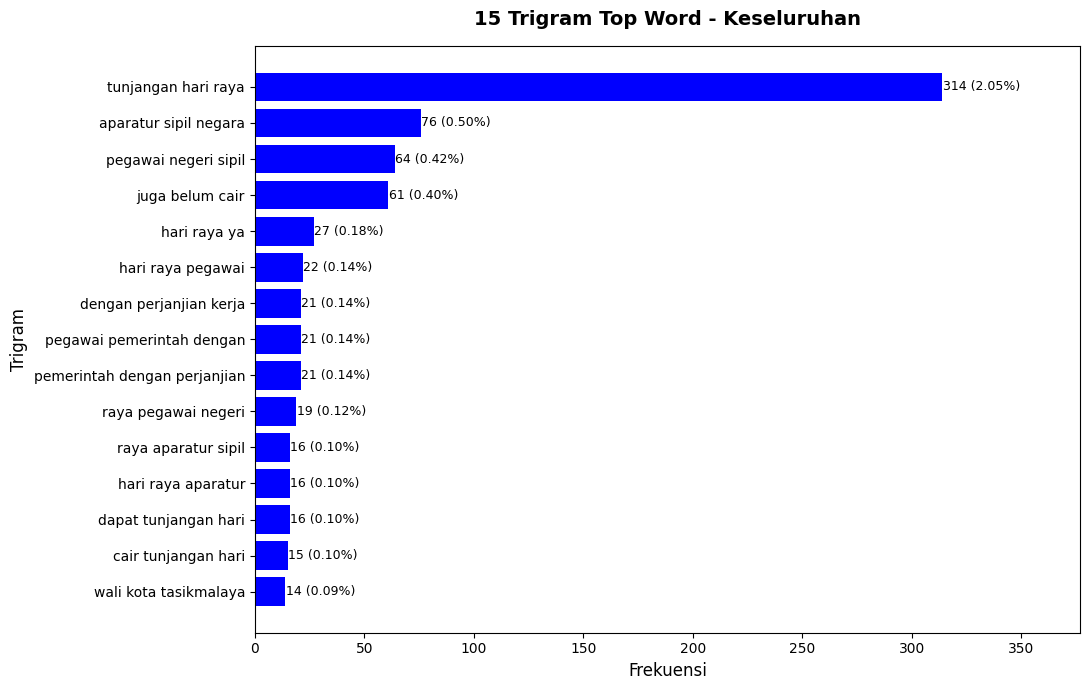

In [15]:
freq_general = plot_top_trigram(
    df_thr,
    sentiment_label=None,
    text_column='normalisasi_kata',
    top_n=15,
    color='blue',
    filename='../img/04 Trigram Top Word General.png'
)

### **4.3.2 Frekuensi Kata Positif - Trigram**

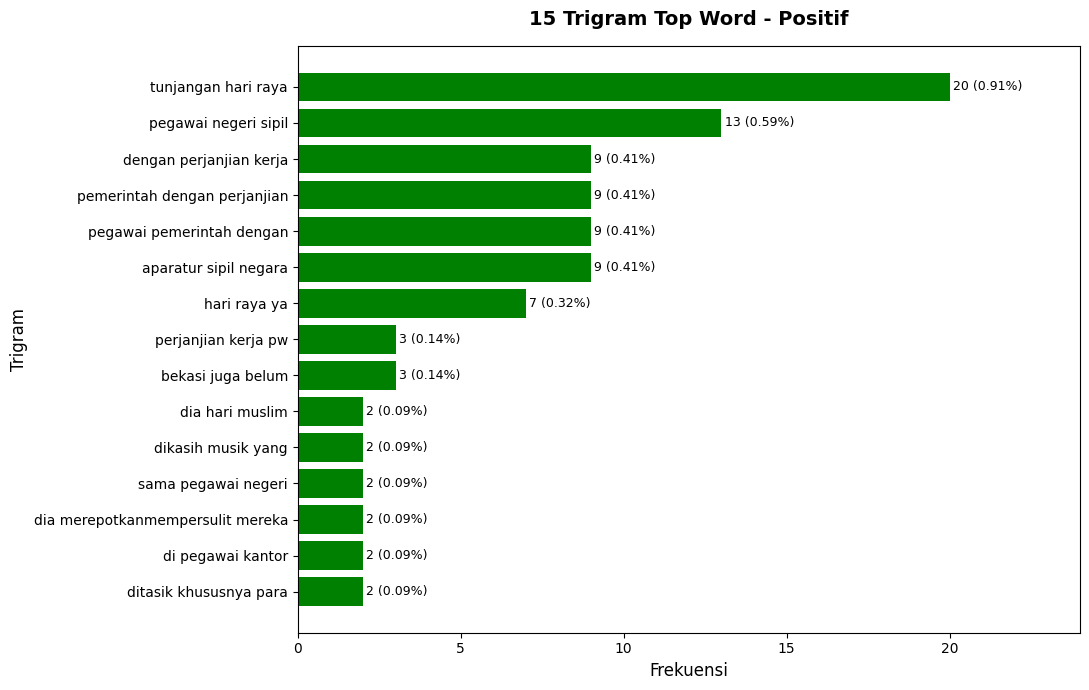

In [16]:
freq_trigram_positif = plot_top_trigram(
    df_thr,
    sentiment_label='Positif',
    text_column='normalisasi_kata',
    top_n=15,
    color='green',
    filename='../img/04 Trigram Top Word Positif.png'
)

### **4.3.3 Frekuensi Kata Negatif - Trigram**

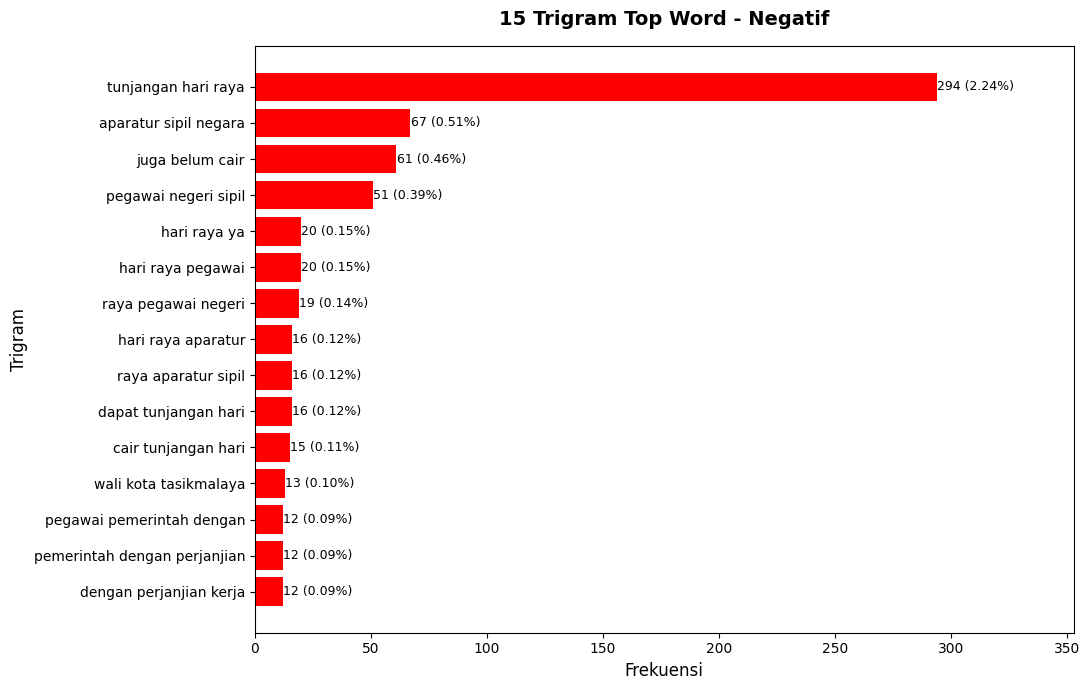

In [17]:
freq_trigram_negatif = plot_top_trigram(
    df_thr,
    sentiment_label='Negatif',
    text_column='normalisasi_kata',
    top_n=15,
    color='red',
    filename='../img/04 Trigram Top Word Negatif.png'
)

### **4.3.2.4 Frekuensi Kata Netral - Trigram**

In [18]:
freq_trigram_netral = plot_top_trigram(
    df_thr,
    sentiment_label='Netral',
    text_column='normalisasi_kata',
    top_n=15,
    color='gray',
    filename='../img/04 Trigram Top Word Netral.png'
)

Tidak ada data untuk 15 Trigram Top Word - Netral
